In [15]:
!load_ext autoreload
!autoreload 2

zsh:1: command not found: load_ext
zsh:1: command not found: autoreload


In [2]:
from __future__ import annotations

"""
Veronesi book-accurate benchmark for the mortgage / RMBS pipeline.

This script is designed to mirror the logic in Pietro Veronesi,
*Fixed Income Securities: Valuation, Risk, and Risk Management*,
Part II / Chapters 11, 12, and 13.

It is intentionally split into the same stages used in the book:

1) Chapter 11:
   - calibrate a Ho-Lee risk-neutral tree
   - calibrate a simple BDT risk-neutral tree
2) Chapter 12:
   - compute the mortgage without prepayment
   - compute the American prepayment option
   - extract trigger rates
   - price pass-through / IO / PO strips on the tree
3) Chapter 13.6:
   - simulate mortgage cash flows on the simple BDT tree using trigger rates
   - compute Monte Carlo price, standard error, and confidence interval

The built-in benchmark run uses the simple BDT mortgage example from Chapters 12-13:
- semiannual grid out to 5 years
- zero prices from Table 12.7
- simple BDT volatility sigma = 21.42%
- mortgage principal = 100,000
- pass-through coupon = 7%

The goal is not to be fancy. The goal is to be logically faithful.
"""

from dataclasses import dataclass
from math import exp, log, sqrt
from typing import List, Optional, Sequence, Tuple, Dict
import random
from statistics import mean, stdev
from scipy.optimize import brentq
import pandas as pd
import numpy as np

# -----------------------------------------------------------------------------
# Data containers
# -----------------------------------------------------------------------------

@dataclass(frozen=True)
class ZeroCurve:
    maturities: Tuple[float, ...]
    zero_prices: Tuple[float, ...]

    @property
    def dt(self) -> float:
        if len(self.maturities) < 2:
            return self.maturities[0]
        steps = [self.maturities[i] - self.maturities[i - 1] for i in range(1, len(self.maturities))]
        first = self.maturities[0]
        all_steps = [first] + steps
        ref = all_steps[0]
        for x in all_steps:
            if abs(x - ref) > 1e-10:
                raise ValueError("Maturities must sit on a regular grid.")
        return ref

@dataclass(frozen=True)
class MortgageSchedule:
    coupon_per_period: float
    interest_paid: Tuple[float, ...]
    principal_paid: Tuple[float, ...]
    outstanding_principal: Tuple[float, ...]

@dataclass(frozen=True)
class TreePricingResult:
    mortgage_rate: float
    coupon_per_period: float
    no_prepay_tree: Tuple[Tuple[float, ...], ...]
    option_tree: Tuple[Tuple[float, ...], ...]
    mortgage_tree: Tuple[Tuple[float, ...], ...]
    trigger_rates: Tuple[float | None, ...]
    schedule: MortgageSchedule

@dataclass(frozen=True)
class MonteCarloSummary:
    mean_value: float
    standard_error: float
    ci_low: float
    ci_high: float

# -----------------------------------------------------------------------------
# Generic tree helpers
# -----------------------------------------------------------------------------

def check_recombining_tree(tree: Sequence[Sequence[float]]) -> None:
    for i, row in enumerate(tree):
        if len(row) != i + 1:
            raise ValueError(f"Level {i} must contain {i+1} nodes, got {len(row)}.")

def tree_zero_price(tree: Sequence[Sequence[float]], maturity_step: int, dt: float) -> float:
    """
    Price a zero-coupon bond maturing at step `maturity_step` on a risk-neutral tree.

    Convention follows the book:
    - risk-neutral probability is p* = 1/2
    - an upward movement keeps j constant
    - a downward movement increments j by 1
    - rates are continuously compounded short rates for each interval of length dt
    """
    check_recombining_tree(tree)
    if maturity_step < 1:
        return 1.0
    values = [1.0] * (maturity_step + 1)
    for i in range(maturity_step - 1, -1, -1):
        next_values = []
        for j in range(i + 1):
            v = exp(-tree[i][j] * dt) * 0.5 * (values[j] + values[j + 1])
            next_values.append(v)
        values = next_values
    return values[0]

def reprice_zero_curve(tree: Sequence[Sequence[float]], dt: float) -> List[float]:
    return [tree_zero_price(tree, m, dt) for m in range(1, len(tree) + 1)]

# -----------------------------------------------------------------------------
# Chapter 11: risk-neutral tree calibration
# -----------------------------------------------------------------------------

def calibrate_simple_bdt_from_zero_prices(
    zero_prices: Sequence[float],
    dt: float,
    sigma: float,
) -> List[List[float]]:
    """
    Calibrate the simple BDT tree exactly to the zero curve.

    Model:
        z_{i+1,j}   = z_{i,j} + theta_i * dt + sigma * sqrt(dt)
        z_{i+1,j+1} = z_{i,j} + theta_i * dt - sigma * sqrt(dt)
        r_{i,j} = exp(z_{i,j})

    Equivalent implementation used here:
        each level i is identified by its top log-rate alpha_i,
        z_{i,j} = alpha_i - 2*j*sigma*sqrt(dt).
    """
    n = len(zero_prices)
    if n < 1:
        raise ValueError("Need at least one zero price.")
    if not (0.0 < zero_prices[0] < 1.0):
        raise ValueError("First zero price must be in (0,1).")

    s = sigma * sqrt(dt)
    tree: List[List[float]] = [[-log(zero_prices[0]) / dt]]
    alphas = [log(tree[0][0])]

    for level in range(1, n):
        target = zero_prices[level]

        def objective(alpha_top: float) -> float:
            row = [exp(alpha_top - 2.0 * j * s) for j in range(level + 1)]
            candidate = tree + [row]
            return tree_zero_price(candidate, level + 1, dt) - target

        lo, hi = -12.0, 4.0
        flo, fhi = objective(lo), objective(hi)
        while flo * fhi > 0:
            lo -= 4.0
            hi += 2.0
            flo, fhi = objective(lo), objective(hi)
            if lo < -200 or hi > 50:
                raise RuntimeError("Failed to bracket simple BDT calibration root.")

        alpha_star = brentq(objective, lo, hi, xtol=1e-14, rtol=1e-12, maxiter=500)
        alphas.append(alpha_star)
        tree.append([exp(alpha_star - 2.0 * j * s) for j in range(level + 1)])

    return tree

def calibrate_ho_lee_from_zero_prices(
    zero_prices: Sequence[float],
    dt: float,
    sigma: float,
) -> List[List[float]]:
    """
    Calibrate the Ho-Lee risk-neutral tree exactly to the zero curve.

    Model:
        r_{i+1,j}   = r_{i,j} + theta_i * dt + sigma * sqrt(dt)
        r_{i+1,j+1} = r_{i,j} + theta_i * dt - sigma * sqrt(dt)

    Equivalent implementation used here:
        each level i is identified by its top rate top_i,
        r_{i,j} = top_i - 2*j*sigma*sqrt(dt).
    """
    n = len(zero_prices)
    if n < 1:
        raise ValueError("Need at least one zero price.")
    first_rate = -log(zero_prices[0]) / dt
    tree: List[List[float]] = [[first_rate]]
    jump = 2.0 * sigma * sqrt(dt)

    for level in range(1, n):
        target = zero_prices[level]

        def objective(top_rate: float) -> float:
            row = [top_rate - j * jump for j in range(level + 1)]
            candidate = tree + [row]
            return tree_zero_price(candidate, level + 1, dt) - target

        # For realistic data there is usually a valid bracket around ordinary rate levels.
        lo, hi = -0.50, 0.80
        flo, fhi = objective(lo), objective(hi)
        while flo * fhi > 0:
            lo -= 0.50
            hi += 0.50
            flo, fhi = objective(lo), objective(hi)
            if lo < -10 or hi > 10:
                raise RuntimeError("Failed to bracket Ho-Lee calibration root.")

        top_star = brentq(objective, lo, hi, xtol=1e-14, rtol=1e-12, maxiter=500)
        tree.append([top_star - j * jump for j in range(level + 1)])

    return tree

# -----------------------------------------------------------------------------
# Chapter 11 empirical sigma utilities
# -----------------------------------------------------------------------------

def estimate_sigma_ho_lee(rate_series: Sequence[float], obs_per_year: float) -> float:
    """Annualized sigma for Ho-Lee = stdev of level changes times sqrt(obs_per_year)."""
    if len(rate_series) < 2:
        raise ValueError("Need at least two observations.")
    diffs = [rate_series[i] - rate_series[i - 1] for i in range(1, len(rate_series))]
    if len(diffs) < 2:
        raise ValueError("Need at least two differences to compute a sample standard deviation.")
    return stdev(diffs) * sqrt(obs_per_year)

def estimate_sigma_simple_bdt(rate_series: Sequence[float], obs_per_year: float) -> float:
    """Annualized sigma for simple BDT = stdev of log-rate changes times sqrt(obs_per_year)."""
    if len(rate_series) < 2:
        raise ValueError("Need at least two observations.")
    if any(r <= 0 for r in rate_series):
        raise ValueError("Simple BDT volatility requires strictly positive rates.")
    diffs = [log(rate_series[i]) - log(rate_series[i - 1]) for i in range(1, len(rate_series))]
    if len(diffs) < 2:
        raise ValueError("Need at least two differences to compute a sample standard deviation.")
    return stdev(diffs) * sqrt(obs_per_year)

# -----------------------------------------------------------------------------
# Chapter 8/12: mortgage schedule and valuation
# -----------------------------------------------------------------------------

def mortgage_schedule(principal: float, annual_rate: float, n_periods: int, dt: float) -> MortgageSchedule:
    """
    Fixed-rate fully amortizing mortgage schedule.

    Continuous compounding is used in the tree discounting, but mortgage coupon cash flows
    in the book example are ordinary discrete semiannual payments.
    """
    if not (principal > 0):
        raise ValueError("Principal must be positive.")
    if not (n_periods >= 1):
        raise ValueError("Need at least one period.")
    if not (dt > 0):
        raise ValueError("dt must be positive.")

    period_rate = annual_rate * dt
    if abs(period_rate) < 1e-16:
        coupon = principal / n_periods
    else:
        coupon = principal * period_rate / (1.0 - (1.0 + period_rate) ** (-n_periods))

    outstanding = [principal]
    interest_paid = [0.0]
    principal_paid = [0.0]

    bal = principal
    for k in range(1, n_periods + 1):
        interest = bal * period_rate
        principal_component = coupon - interest
        # clean up final period rounding drift
        if k == n_periods:
            principal_component = bal
            coupon_k = interest + principal_component
        else:
            coupon_k = coupon
        bal = bal - principal_component
        if abs(bal) < 1e-10:
            bal = 0.0
        interest_paid.append(interest)
        principal_paid.append(principal_component)
        outstanding.append(bal)
        coupon = coupon_k  # only changes in the final period if rounding was corrected

    # Keep the book convention: coupon amount is constant except for tiny numerical cleanup.
    coupon_per_period = interest_paid[1] + principal_paid[1]
    return MortgageSchedule(
        coupon_per_period=coupon_per_period,
        interest_paid=tuple(interest_paid),
        principal_paid=tuple(principal_paid),
        outstanding_principal=tuple(outstanding),
    )

def price_no_prepay_mortgage(
    tree: Sequence[Sequence[float]],
    coupon_per_period: float,
    dt: float,
) -> List[List[float]]:
    """
    Chapter 12 recursion for the mortgage without the prepayment option:
        V^np_{i,j} = exp(-r_{i,j} dt) * (0.5 V^np_{i+1,j} + 0.5 V^np_{i+1,j+1} + C)
    with terminal value 0 at maturity.
    """
    check_recombining_tree(tree)
    n = len(tree)
    values: List[List[float]] = [[0.0] * (i + 1) for i in range(n + 1)]
    for i in range(n - 1, -1, -1):
        for j in range(i + 1):
            cont = 0.5 * values[i + 1][j] + 0.5 * values[i + 1][j + 1] + coupon_per_period
            values[i][j] = exp(-tree[i][j] * dt) * cont
    return values

def price_prepayment_option(
    tree: Sequence[Sequence[float]],
    no_prepay_tree: Sequence[Sequence[float]],
    outstanding_principal: Sequence[float],
    dt: float,
) -> List[List[float]]:
    """
    Chapter 12 American refinancing option logic.

    Exercise payoff:
        C^Exercise_{i,j} = max(V^np_{i,j} - L_i, 0)
    Wait value:
        C^Wait_{i,j} = exp(-r_{i,j} dt) * 0.5 * (C_{i+1,j} + C_{i+1,j+1})
    Option value:
        C_{i,j} = max(C^Wait_{i,j}, C^Exercise_{i,j})

    Important: to match the book literally, trigger extraction later uses the strict rule
    "exercise when exercise value > wait value".
    """
    check_recombining_tree(tree)
    n = len(tree)
    option: List[List[float]] = [[0.0] * (i + 1) for i in range(n + 1)]
    for i in range(n - 1, -1, -1):
        Li = outstanding_principal[i]
        for j in range(i + 1):
            wait = exp(-tree[i][j] * dt) * 0.5 * (option[i + 1][j] + option[i + 1][j + 1])
            if i == 0:
                # Book benchmark: no immediate refinancing at initiation.
                option[i][j] = wait
            else:
                exercise = max(no_prepay_tree[i][j] - Li, 0.0)
                option[i][j] = max(wait, exercise)
    return option

def extract_trigger_rates(
    tree: Sequence[Sequence[float]],
    no_prepay_tree: Sequence[Sequence[float]],
    option_tree: Sequence[Sequence[float]],
    outstanding_principal: Sequence[float],
    dt: float,
) -> List[float | None]:
    """
    Extract the trigger rate in each period i using the book's strict exercise test:
    refinance whenever C^Exercise_{i,j} > C^Wait_{i,j}.

    The trigger is reported as the highest rate at which strict exercise is optimal in period i.
    If no node exercises, trigger is None.
    """
    n = len(tree)
    triggers: List[float | None] = [None] * (n + 1)
    triggers[0] = None
    for i in range(1, n):
        Li = outstanding_principal[i]
        exercising_rates: List[float] = []
        for j in range(i + 1):
            exercise = max(no_prepay_tree[i][j] - Li, 0.0)
            wait = exp(-tree[i][j] * dt) * 0.5 * (option_tree[i + 1][j] + option_tree[i + 1][j + 1])
            if exercise > wait:
                exercising_rates.append(tree[i][j])
        triggers[i] = max(exercising_rates) if exercising_rates else None
    triggers[n] = None
    return triggers

def mortgage_tree_from_components(
    no_prepay_tree: Sequence[Sequence[float]],
    option_tree: Sequence[Sequence[float]],
) -> List[List[float]]:
    return [
        [no_prepay_tree[i][j] - option_tree[i][j] for j in range(i + 1)]
        for i in range(len(no_prepay_tree))
    ]

def solve_par_mortgage_rate(
    tree: Sequence[Sequence[float]],
    principal: float,
    dt: float,
) -> TreePricingResult:
    """
    Solve for the mortgage rate such that mortgage value at inception equals principal.
    """
    n_periods = len(tree)

    def objective(annual_rate: float) -> float:
        sched = mortgage_schedule(principal=principal, annual_rate=annual_rate, n_periods=n_periods, dt=dt)
        vnp = price_no_prepay_mortgage(tree, sched.coupon_per_period, dt)
        opt = price_prepayment_option(tree, vnp, sched.outstanding_principal, dt)
        mort0 = vnp[0][0] - opt[0][0]
        return mort0 - principal

    lo, hi = 1e-6, 0.50
    flo, fhi = objective(lo), objective(hi)
    while flo * fhi > 0:
        hi *= 1.5
        fhi = objective(hi)
        if hi > 5.0:
            raise RuntimeError("Failed to bracket mortgage-rate root.")

    rate_star = brentq(objective, lo, hi, xtol=1e-14, rtol=1e-12, maxiter=500)
    sched = mortgage_schedule(principal=principal, annual_rate=rate_star, n_periods=n_periods, dt=dt)
    vnp = price_no_prepay_mortgage(tree, sched.coupon_per_period, dt)
    opt = price_prepayment_option(tree, vnp, sched.outstanding_principal, dt)
    mort = mortgage_tree_from_components(vnp, opt)
    triggers = extract_trigger_rates(tree, vnp, opt, sched.outstanding_principal, dt)
    return TreePricingResult(
        mortgage_rate=rate_star,
        coupon_per_period=sched.coupon_per_period,
        no_prepay_tree=tuple(tuple(row) for row in vnp),
        option_tree=tuple(tuple(row) for row in opt),
        mortgage_tree=tuple(tuple(row) for row in mort),
        trigger_rates=tuple(triggers),
        schedule=sched,
    )

# -----------------------------------------------------------------------------
# Chapter 12: pass-through / IO / PO pricing on the tree
# -----------------------------------------------------------------------------

def price_pass_through_on_tree(
    tree: Sequence[Sequence[float]],
    outstanding_principal: Sequence[float],
    scheduled_principal: Sequence[float],
    trigger_rates: Sequence[float | None],
    pass_through_rate: float,
    dt: float,
) -> List[List[float]]:
    """
    Chapter 12 pass-through recursion.

    If prepayment occurs at node (i,j):
        PPT_{i,j} = L_i
    Otherwise:
        PPT_{i,j} = exp(-r_{i,j} dt) * (0.5 next_up + 0.5 next_down + CF(i+1))
    where CF(i+1) = pass-through interest on L_i plus scheduled principal at i+1.
    """
    n = len(tree)
    pt = [[0.0] * (i + 1) for i in range(n + 1)]
    for i in range(n - 1, -1, -1):
        Li = outstanding_principal[i]
        cf_next = Li * pass_through_rate * dt + scheduled_principal[i + 1]
        trig = trigger_rates[i]
        for j in range(i + 1):
            r = tree[i][j]
            if trig is not None and r <= trig:
                pt[i][j] = outstanding_principal[i]
            else:
                pt[i][j] = exp(-r * dt) * (0.5 * pt[i + 1][j] + 0.5 * pt[i + 1][j + 1] + cf_next)
    return pt

def price_po_on_tree(
    tree: Sequence[Sequence[float]],
    outstanding_principal: Sequence[float],
    scheduled_principal: Sequence[float],
    trigger_rates: Sequence[float | None],
    dt: float,
) -> List[List[float]]:
    n = len(tree)
    po = [[0.0] * (i + 1) for i in range(n + 1)]
    for i in range(n - 1, -1, -1):
        Li = outstanding_principal[i]
        principal_cf_next = scheduled_principal[i + 1]
        trig = trigger_rates[i]
        for j in range(i + 1):
            r = tree[i][j]
            if trig is not None and r <= trig:
                po[i][j] = outstanding_principal[i]
            else:
                po[i][j] = exp(-r * dt) * (0.5 * po[i + 1][j] + 0.5 * po[i + 1][j + 1] + principal_cf_next)
    return po

def price_io_on_tree(
    tree: Sequence[Sequence[float]],
    outstanding_principal: Sequence[float],
    trigger_rates: Sequence[float | None],
    pass_through_rate: float,
    dt: float,
) -> List[List[float]]:
    n = len(tree)
    io = [[0.0] * (i + 1) for i in range(n + 1)]
    for i in range(n - 1, -1, -1):
        Li = outstanding_principal[i]
        interest_cf_next = Li * pass_through_rate * dt
        trig = trigger_rates[i]
        for j in range(i + 1):
            r = tree[i][j]
            if trig is not None and r <= trig:
                io[i][j] = 0.0
            else:
                io[i][j] = exp(-r * dt) * (0.5 * io[i + 1][j] + 0.5 * io[i + 1][j + 1] + interest_cf_next)
    return io

# -----------------------------------------------------------------------------
# Chapter 13.6.1: Monte Carlo mortgage valuation on the tree using trigger rates
# -----------------------------------------------------------------------------

def simulate_tree_path_indices(n_intervals: int, rng: random.Random) -> List[int]:
    """Return j-indices for tree levels 0..n_intervals-1 along one risk-neutral path."""
    j = 0
    path = [0]
    for _ in range(1, n_intervals):
        u = rng.random()
        if u >= 0.5:
            j += 1  # downward movement in the book's indexing
        path.append(j)
    return path

def discount_factor_along_path(tree: Sequence[Sequence[float]], path_j: Sequence[int], k: int, dt: float) -> float:
    """Discount from time 0 to payment date T_k using rates on intervals 0..k-1."""
    accum = 0.0
    for m in range(k):
        accum += tree[m][path_j[m]]
    return exp(-accum * dt)

def price_mortgage_mc_trigger_rule(
    tree: Sequence[Sequence[float]],
    schedule: MortgageSchedule,
    trigger_rates: Sequence[float | None],
    dt: float,
    n_sims: int = 100000,
    seed: int = 12345,
) -> MonteCarloSummary:
    """
    Chapter 13.6.1 benchmark mortgage Monte Carlo.

    Logic:
    - simulate short-rate paths on the simple BDT tree with p*=1/2
    - at payment date k, inspect the short rate for period k (tree level k)
    - if it falls below the trigger for that period, prepay the whole remaining principal
      at that payment date together with the scheduled interest for that date
    - before trigger is hit, only scheduled coupon cash flows are paid
    - average discounted path values over simulations
    """
    rng = random.Random(seed)
    n = len(tree)  # number of payment dates
    path_values: List[float] = []

    for _ in range(n_sims):
        path_j = simulate_tree_path_indices(n, rng)
        pv = 0.0
        prepaid = False

        for k in range(1, n + 1):
            df = discount_factor_along_path(tree, path_j, k, dt)
            scheduled_interest = schedule.interest_paid[k]
            scheduled_principal = schedule.principal_paid[k]

            if k < n:
                rate_at_payment_date = tree[k][path_j[k]]
                trig = trigger_rates[k]
            else:
                rate_at_payment_date = None
                trig = None

            if (not prepaid) and (k < n) and (trig is not None) and (rate_at_payment_date is not None) and (rate_at_payment_date <= trig):
                # Book-consistent prepayment cash flow: scheduled interest at k + full outstanding
                # principal before the k-th scheduled principal payment.
                cashflow = scheduled_interest + schedule.outstanding_principal[k - 1]
                pv += df * cashflow
                prepaid = True
                break
            else:
                cashflow = scheduled_interest + scheduled_principal
                pv += df * cashflow

        path_values.append(pv)

    mu = mean(path_values)
    se = stdev(path_values) / sqrt(n_sims)
    return MonteCarloSummary(mu, se, mu - 2.0 * se, mu + 2.0 * se)

# -----------------------------------------------------------------------------
# Reporting helpers
# -----------------------------------------------------------------------------

def fmt_pct(x: float | None, digits: int = 2) -> str:
    if x is None:
        return "-"
    return f"{100.0 * x:.{digits}f}%"

def fmt_money(x: float, digits: int = 0) -> str:
    return f"${x:,.{digits}f}"

def print_tree_slice(name: str, tree: Sequence[Sequence[float]], levels: int = 5, pct: bool = True) -> None:
    print(f"\n{name} (first {levels} levels)")
    for i, row in enumerate(tree[:levels]):
        formatted = []
        for x in row:
            formatted.append(f"{100*x:8.4f}%" if pct else f"{x:12.6f}")
        print(f"level {i:>2}: " + " ".join(formatted))

In [3]:
# =============================================================================
# Components you can switch on/off
# =============================================================================

@dataclass(frozen=True)
class ExogenousComponent:
    annual_hazard: float = 0.04
    seasoning_periods: int = 4
    seasonality: Optional[Tuple[float, ...]] = None

@dataclass(frozen=True)
class RefiLogitComponent:
    # q_refi = logistic(beta0 + beta1 * incentive)
    beta0: float = -2.50
    beta1: float = 35.0
    gate_by_optimality: bool = True

@dataclass(frozen=True)
class BurnoutComponent:
    gamma: float = 1.00

@dataclass(frozen=True)
class PrepayModel:
    # Base benchmark from part (e): deterministic optimal refinance
    deterministic_optimal_refi: bool = False

    # Optional add-ons
    exogenous: Optional[ExogenousComponent] = None
    refi: Optional[RefiLogitComponent] = None
    burnout: Optional[BurnoutComponent] = None

# =============================================================================
# Prepared inputs for part (f)
# =============================================================================

@dataclass(frozen=True)
class PreparedPartFInputs:
    tree: Tuple[Tuple[float, ...], ...]
    dt: float
    pricing_result: TreePricingResult
    incentive_tree: Tuple[Tuple[float, ...], ...]

@dataclass(frozen=True)
class PathDecision:
    path_j: Tuple[int, ...]
    prepay_period: Optional[int]
    prepay_cause: Optional[str]   # "exo", "refi", "deterministic_refi", or None

@dataclass(frozen=True)
class PartFValuationSummary:
    mortgage: MonteCarloSummary
    pt: MonteCarloSummary
    io: MonteCarloSummary
    po: MonteCarloSummary
    mortgage_rate: float
    pass_through_rate: float
    prepay_probability: float
    avg_prepay_time_years: Optional[float]
    cause_shares: Dict[str, float]

# =============================================================================
# Small helpers
# =============================================================================

def _summary(xs: Sequence[float]) -> MonteCarloSummary:
    mu = mean(xs)
    se = stdev(xs) / sqrt(len(xs))
    z = 1.96
    return MonteCarloSummary(
        mean_value=mu,
        standard_error=se,
        ci_low=mu - z * se,
        ci_high=mu + z * se,
    )

def logistic(x: float) -> float:
    if x >= 0.0:
        e = exp(-x)
        return 1.0 / (1.0 + e)
    e = exp(x)
    return e / (1.0 + e)

def default_seasonality_semiannual(n_periods: int) -> Tuple[float, ...]:
    # Example only. Replace with your own calibration if needed.
    return tuple(0.90 if (k % 2 == 1) else 1.10 for k in range(1, n_periods + 1))

# =============================================================================
# Build reusable mortgage / tree inputs
# =============================================================================

def build_refinancing_incentive_tree(
    no_prepay_tree: Sequence[Sequence[float]],
    outstanding_principal: Sequence[float],
) -> List[List[float]]:
    """
    incentive_{i,j} = max(V_np(i,j) - L_i, 0) / L_i
    """
    out: List[List[float]] = []

    for i in range(len(no_prepay_tree)):
        Li = outstanding_principal[i] if i < len(outstanding_principal) else 0.0
        row: List[float] = []
        for j in range(len(no_prepay_tree[i])):
            if Li <= 1e-12:
                row.append(0.0)
            else:
                row.append(max(no_prepay_tree[i][j] - Li, 0.0) / Li)
        out.append(row)

    return out

def prepare_part_f_inputs(
    tree: Sequence[Sequence[float]],
    pricing_result: TreePricingResult,
    dt: float,
) -> PreparedPartFInputs:
    incentive_tree = build_refinancing_incentive_tree(
        no_prepay_tree=pricing_result.no_prepay_tree,
        outstanding_principal=pricing_result.schedule.outstanding_principal,
    )

    return PreparedPartFInputs(
        tree=tuple(tuple(row) for row in tree),
        dt=dt,
        pricing_result=pricing_result,
        incentive_tree=tuple(tuple(row) for row in incentive_tree),
    )

def pricing_result_for_fixed_rate(
    tree: Sequence[Sequence[float]],
    principal: float,
    annual_rate: float,
    dt: float,
) -> TreePricingResult:
    """
    Rebuild schedule / no-prepay tree / option tree / trigger rates
    for a given mortgage rate.
    """
    n_periods = len(tree)

    sched = mortgage_schedule(
        principal=principal,
        annual_rate=annual_rate,
        n_periods=n_periods,
        dt=dt,
    )

    vnp = price_no_prepay_mortgage(
        tree=tree,
        coupon_per_period=sched.coupon_per_period,
        dt=dt,
    )

    opt = price_prepayment_option(
        tree=tree,
        no_prepay_tree=vnp,
        outstanding_principal=sched.outstanding_principal,
        dt=dt,
    )

    mort = mortgage_tree_from_components(vnp, opt)

    triggers = extract_trigger_rates(
        tree=tree,
        no_prepay_tree=vnp,
        option_tree=opt,
        outstanding_principal=sched.outstanding_principal,
        dt=dt,
    )

    return TreePricingResult(
        mortgage_rate=annual_rate,
        coupon_per_period=sched.coupon_per_period,
        no_prepay_tree=tuple(tuple(row) for row in vnp),
        option_tree=tuple(tuple(row) for row in opt),
        mortgage_tree=tuple(tuple(row) for row in mort),
        trigger_rates=tuple(triggers),
        schedule=sched,
    )

# =============================================================================
# Factor modules
# =============================================================================

def build_exogenous_probs(
    n_periods: int,
    dt: float,
    exogenous: ExogenousComponent,
) -> List[float]:
    """
    p_k = 1 - exp(-lambda_k * dt)
    lambda_k = base_hazard * seasoning_k * seasonality_k
    """
    seasonality = exogenous.seasonality
    if seasonality is None:
        seasonality = default_seasonality_semiannual(n_periods)

    if len(seasonality) != n_periods:
        raise ValueError("seasonality must have one value per payment period")

    probs: List[float] = []
    for k in range(1, n_periods + 1):
        if exogenous.seasoning_periods <= 0:
            seasoning = 1.0
        else:
            seasoning = min(k / exogenous.seasoning_periods, 1.0)

        lam = exogenous.annual_hazard * seasoning * seasonality[k - 1]
        p = 1.0 - exp(-lam * dt)
        probs.append(min(max(p, 0.0), 1.0))

    return probs

def is_optimal_refi(
    rate: float,
    trigger_rate: Optional[float],
    incentive: float,
) -> bool:
    if trigger_rate is None:
        return False
    if incentive <= 0.0:
        return False
    return rate <= trigger_rate

def refi_probability(
    rate: float,
    trigger_rate: Optional[float],
    incentive: float,
    burnout_state: float,
    refi: RefiLogitComponent,
    burnout: Optional[BurnoutComponent],
) -> float:
    if refi.gate_by_optimality and not is_optimal_refi(rate, trigger_rate, incentive):
        return 0.0

    q = logistic(refi.beta0 + refi.beta1 * incentive)

    if burnout is not None:
        q *= exp(-burnout.gamma * burnout_state)

    return min(max(q, 0.0), 1.0)

# =============================================================================
# One path: build from base, then add factors
# =============================================================================

def simulate_prepayment_path(
    prepared: PreparedPartFInputs,
    model: PrepayModel,
    rng: random.Random,
) -> PathDecision:
    """
    Modular structure:
      base                    -> deterministic optimal refinance
      + exogenous             -> extra turnover-style prepayment
      + refi                  -> replace deterministic rule with stochastic refi
      + burnout               -> damp stochastic refi after repeated low-rate episodes
    """
    n = len(prepared.tree)
    path_j = simulate_tree_path_indices(n, rng)

    exo_probs = None
    if model.exogenous is not None:
        exo_probs = build_exogenous_probs(
            n_periods=n,
            dt=prepared.dt,
            exogenous=model.exogenous,
        )

    burnout_state = 0.0

    for k in range(1, n):
        j = path_j[k]
        r = prepared.tree[k][j]
        trigger = prepared.pricing_result.trigger_rates[k]
        incentive = prepared.incentive_tree[k][j]
        optimal = is_optimal_refi(r, trigger, incentive)

        # 1) Base benchmark: deterministic optimal refinance
        if model.deterministic_optimal_refi and optimal:
            return PathDecision(tuple(path_j), k, "deterministic_refi")

        # 2) Add exogenous prepayment
        if exo_probs is not None:
            if rng.random() < exo_probs[k - 1]:
                return PathDecision(tuple(path_j), k, "exo")

        # 3) Add stochastic refi
        if model.refi is not None:
            q = refi_probability(
                rate=r,
                trigger_rate=trigger,
                incentive=incentive,
                burnout_state=burnout_state,
                refi=model.refi,
                burnout=model.burnout,
            )
            if rng.random() < q:
                return PathDecision(tuple(path_j), k, "refi")

        # 4) Update burnout state after surviving this period
        if model.burnout is not None:
            burnout_state += incentive

    return PathDecision(tuple(path_j), None, None)

# =============================================================================
# Pathwise valuation
# =============================================================================

def pv_mortgage_on_path(
    tree: Sequence[Sequence[float]],
    schedule: MortgageSchedule,
    path_j: Sequence[int],
    prepay_period: Optional[int],
    dt: float,
) -> float:
    n = len(tree)
    pv = 0.0

    for k in range(1, n + 1):
        df = discount_factor_along_path(tree, path_j, k, dt)
        scheduled_interest = schedule.interest_paid[k]
        scheduled_principal = schedule.principal_paid[k]

        if prepay_period is not None and k == prepay_period:
            outstanding_before_payment = schedule.outstanding_principal[k - 1]
            pv += df * (scheduled_interest + outstanding_before_payment)
            break

        pv += df * (scheduled_interest + scheduled_principal)

    return pv


def pv_pt_io_po_on_path(
    tree: Sequence[Sequence[float]],
    schedule: MortgageSchedule,
    path_j: Sequence[int],
    prepay_period: Optional[int],
    pass_through_rate: float,
    dt: float,
) -> Tuple[float, float, float]:
    n = len(tree)
    pt_pv = 0.0
    io_pv = 0.0
    po_pv = 0.0

    for k in range(1, n + 1):
        df = discount_factor_along_path(tree, path_j, k, dt)
        outstanding_before_payment = schedule.outstanding_principal[k - 1]
        scheduled_principal = schedule.principal_paid[k]
        pt_interest = outstanding_before_payment * pass_through_rate * dt

        if prepay_period is not None and k == prepay_period:
            pt_pv += df * (pt_interest + outstanding_before_payment)
            io_pv += df * pt_interest
            po_pv += df * outstanding_before_payment
            break

        pt_pv += df * (pt_interest + scheduled_principal)
        io_pv += df * pt_interest
        po_pv += df * scheduled_principal

    return pt_pv, io_pv, po_pv

# =============================================================================
# Main valuation engine
# =============================================================================

def value_part_f_model(
    prepared: PreparedPartFInputs,
    model: PrepayModel,
    pass_through_rate: float,
    n_sims: int = 100_000,
    seed: int = 12345,
) -> PartFValuationSummary:
    rng = random.Random(seed)

    mortgage_vals: List[float] = []
    pt_vals: List[float] = []
    io_vals: List[float] = []
    po_vals: List[float] = []

    prepay_periods: List[int] = []
    cause_counts = {
        "deterministic_refi": 0,
        "exo": 0,
        "refi": 0,
    }

    for _ in range(n_sims):
        decision = simulate_prepayment_path(
            prepared=prepared,
            model=model,
            rng=rng,
        )

        mortgage_vals.append(
            pv_mortgage_on_path(
                tree=prepared.tree,
                schedule=prepared.pricing_result.schedule,
                path_j=decision.path_j,
                prepay_period=decision.prepay_period,
                dt=prepared.dt,
            )
        )

        pt_pv, io_pv, po_pv = pv_pt_io_po_on_path(
            tree=prepared.tree,
            schedule=prepared.pricing_result.schedule,
            path_j=decision.path_j,
            prepay_period=decision.prepay_period,
            pass_through_rate=pass_through_rate,
            dt=prepared.dt,
        )
        pt_vals.append(pt_pv)
        io_vals.append(io_pv)
        po_vals.append(po_pv)

        if decision.prepay_period is not None:
            prepay_periods.append(decision.prepay_period)
            if decision.prepay_cause is not None:
                cause_counts[decision.prepay_cause] += 1

    total_prepays = len(prepay_periods)
    prepay_probability = total_prepays / n_sims
    avg_prepay_time_years = mean(prepay_periods) * prepared.dt if total_prepays > 0 else None

    if total_prepays > 0:
        cause_shares = {k: v / total_prepays for k, v in cause_counts.items()}
    else:
        cause_shares = {k: 0.0 for k in cause_counts}

    return PartFValuationSummary(
        mortgage=_summary(mortgage_vals),
        pt=_summary(pt_vals),
        io=_summary(io_vals),
        po=_summary(po_vals),
        mortgage_rate=prepared.pricing_result.mortgage_rate,
        pass_through_rate=pass_through_rate,
        prepay_probability=prepay_probability,
        avg_prepay_time_years=avg_prepay_time_years,
        cause_shares=cause_shares,
    )

# =============================================================================
# Solve new mortgage rate under a chosen model
# =============================================================================

def solve_par_rate_part_f(
    tree: Sequence[Sequence[float]],
    principal: float,
    dt: float,
    model: PrepayModel,
    n_sims: int = 100_000,
    seed: int = 12345,
    rate_lo: float = 1e-4,
    rate_hi: float = 0.25,
) -> float:
    """
    Solve for K such that MC mortgage value under the chosen part-(f) model is par.
    """
    def objective(annual_rate: float) -> float:
        pricing_result = pricing_result_for_fixed_rate(
            tree=tree,
            principal=principal,
            annual_rate=annual_rate,
            dt=dt,
        )

        prepared = prepare_part_f_inputs(
            tree=tree,
            pricing_result=pricing_result,
            dt=dt,
        )

        out = value_part_f_model(
            prepared=prepared,
            model=model,
            pass_through_rate=annual_rate - 0.005,   # harmless for root search
            n_sims=n_sims,
            seed=seed,                               # common random numbers
        )
        return out.mortgage.mean_value - principal

    lo = rate_lo
    hi = rate_hi
    flo = objective(lo)
    fhi = objective(hi)

    while flo * fhi > 0:
        hi *= 1.5
        fhi = objective(hi)
        if hi > 5.0:
            raise RuntimeError("Failed to bracket root in solve_par_rate_part_f.")

    return brentq(objective, lo, hi, xtol=1e-10, rtol=1e-8, maxiter=100)

# =============================================================================
# Compare models side by side
# =============================================================================

def compare_part_f_models(
    prepared: PreparedPartFInputs,
    models: Dict[str, PrepayModel],
    pass_through_rate: float,
    n_sims: int = 100_000,
    seed: int = 12345,
) -> List[Dict[str, float]]:
    rows = []

    for name, model in models.items():
        out = value_part_f_model(
            prepared=prepared,
            model=model,
            pass_through_rate=pass_through_rate,
            n_sims=n_sims,
            seed=seed,
        )

        rows.append({
            "model": name,
            "mortgage_value": out.mortgage.mean_value,
            "mortgage_ci_low": out.mortgage.ci_low,
            "mortgage_ci_high": out.mortgage.ci_high,
            "pt_value": out.pt.mean_value,
            "io_value": out.io.mean_value,
            "po_value": out.po.mean_value,
            "prepay_probability": out.prepay_probability,
            "avg_prepay_time_years": out.avg_prepay_time_years if out.avg_prepay_time_years is not None else float("nan"),
            "share_deterministic_refi": out.cause_shares["deterministic_refi"],
            "share_exo": out.cause_shares["exo"],
            "share_refi": out.cause_shares["refi"],
        })

    return rows

**Data source.** I use the **Bank of England’s official yield-curve archive**, specifically the **Daily overnight index swap (OIS) curve: archive data** downloaded from the Bank’s yield-curves statistics page. The OIS curve is a sterling risk-free term structure derived from overnight index swap rates and is a reputable public source for UK interest-rate modelling. The Bank states that the published **spot and forward yields are continuously compounded and quoted on an annual basis**. For non-gilt instruments such as OIS, the Bank uses the **Actual/365** day-count convention. ([Bank of England][1])

[1]: https://www.bankofengland.co.uk/-/media/boe/files/statistics/yield-curves/frequently-asked-questions-yield-curves.pdf?utm_source=chatgpt.com "Yield Curves - Frequently Asked Questions"


In [4]:
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# BoE GLC nominal zero curve for tree calibration
# -----------------------------------------------------------------------------

PARQUET_FILE = "data/boe_glc_nominal_daily_spot_curve.parquet"
VALUATION_DATE = "2026-01-30"

DT = 0.5
T = 10.0
grid = np.arange(DT, T + 1e-12, DT)

data = pd.read_parquet(PARQUET_FILE)

data.columns = ["date"] + [float(c) for c in data.columns[1:]]

# choose the latest available BoE curve on or before the valuation date
valuation_date = pd.Timestamp(VALUATION_DATE)
curve_date = data.loc[data["date"] <= valuation_date, "date"].max()

if pd.isna(curve_date):
    raise ValueError(f"No curve available on or before {VALUATION_DATE}.")

curve_day = (
    data.loc[data["date"] == curve_date]
    .drop(columns="date")
    .iloc[0]
    .dropna()
    .astype(float)
)

# observed BoE spot curve
# BoE spot yields are quoted in percent; convert to decimals
t_obs = curve_day.index.to_numpy(dtype=float)
z_obs = curve_day.to_numpy(dtype=float) / 100.0

# keep only positive maturities
mask = t_obs > 0
t_obs = t_obs[mask]
z_obs = z_obs[mask]

# -----------------------------------------------------------------------------
# Convert cc zero yields to zero-coupon prices
# P(0,t) = exp(-z(t) * t)
# Then interpolate linearly in log-discount factors
# -----------------------------------------------------------------------------

P_obs = np.exp(-z_obs * t_obs)

if grid.max() > t_obs.max():
    raise ValueError(
        f"Target grid goes to {grid.max():.1f}y but curve only goes to {t_obs.max():.1f}y."
    )

logP_grid = np.interp(grid, t_obs, np.log(P_obs))
P_market = np.exp(logP_grid)
z_grid = -np.log(P_market) / grid

market_curve = pd.DataFrame({
    "curve_date": curve_date,
    "t": grid,
    "zero_rate_cc": z_grid,
    "zero_price": P_market,
})

print(market_curve)

   curve_date     t  zero_rate_cc  zero_price
0  2026-01-30   0.5      0.034786    0.982758
1  2026-01-30   1.0      0.035482    0.965140
2  2026-01-30   1.5      0.035931    0.947531
3  2026-01-30   2.0      0.036282    0.930006
4  2026-01-30   2.5      0.036709    0.912312
5  2026-01-30   3.0      0.037217    0.894355
6  2026-01-30   3.5      0.037786    0.876120
7  2026-01-30   4.0      0.038398    0.857623
8  2026-01-30   4.5      0.039041    0.838883
9  2026-01-30   5.0      0.039707    0.819931
10 2026-01-30   5.5      0.040389    0.800802
11 2026-01-30   6.0      0.041081    0.781544
12 2026-01-30   6.5      0.041774    0.762212
13 2026-01-30   7.0      0.042463    0.742864
14 2026-01-30   7.5      0.043143    0.723562
15 2026-01-30   8.0      0.043808    0.704361
16 2026-01-30   8.5      0.044456    0.685316
17 2026-01-30   9.0      0.045084    0.666474
18 2026-01-30   9.5      0.045690    0.647876
19 2026-01-30  10.0      0.046274    0.629557


Ho–Lee volatility is estimated empirically from monthly changes in the 6-month GLC nominal spot rate over the modern 2016–2026 sample. For simple BDT, direct estimation from log-rate changes is unstable in the near-zero-rate era, so I use the approximation $\sigma_{BDT}\approx \sigma_{HL}/r_0$, where $r_0$ is the current 6-month spot rate. This is a pragmatic modern-data workaround rather than the textbook historical log-volatility estimate. Veronesi notes both that simple BDT is a log-rate model and that it performs poorly in low-rate environments.

In [5]:
MONTHLY_PARQUET = "data/boe_glc_nominal_monthly_spot_curve.parquet"

# modern window for HL sigma
SIGMA_START = "2016-01-31"

monthly_hist = pd.read_parquet(MONTHLY_PARQUET)
monthly_hist.columns = ["date"] + [float(c) for c in monthly_hist.columns[1:]]

r6m = (
    monthly_hist.loc[
        (monthly_hist["date"] >= pd.Timestamp(SIGMA_START)) &
        (monthly_hist["date"] <= valuation_date),
        ["date", 0.5]
    ]
    .rename(columns={0.5: "rate_pct"})
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)

# convert % to decimal
r6m["rate"] = r6m["rate_pct"] / 100.0

# month spacing
r6m["month_period"] = r6m["date"].dt.to_period("M")
r6m["month_gap"] = r6m["month_period"].diff().apply(
    lambda x: x.n if pd.notna(x) else np.nan
)

# Ho-Lee sigma from level changes
r6m["dr"] = r6m["rate"].diff()
dr = r6m.loc[r6m["month_gap"] == 1, "dr"].dropna()

sigma_hl = dr.std(ddof=1) * np.sqrt(12.0)

# Current 6m rate from valuation-date market curve
r0 = float(market_curve.loc[np.isclose(market_curve["t"], 0.5), "zero_rate_cc"].iloc[0])

# Practical workaround for simple BDT in the low-rate era
sigma_bdt = sigma_hl / r0

sigma_summary = pd.DataFrame([{
    "series_used": "GLC nominal 6m spot",
    "window_start": r6m["date"].min().date(),
    "window_end": r6m["date"].max().date(),
    "n_level_obs": len(r6m),
    "hl_n_changes_used": len(dr),
    "mean_6m_rate": r6m["rate"].mean(),
    "current_6m_rate_r0": r0,
    "sigma_hl": sigma_hl,
    "sigma_bdt_workaround": sigma_bdt,
}])

print(sigma_summary.to_string(index=False))

        series_used window_start window_end  n_level_obs  hl_n_changes_used  mean_6m_rate  current_6m_rate_r0  sigma_hl  sigma_bdt_workaround
GLC nominal 6m spot   2016-03-31 2026-01-30           89                 76      0.015565            0.034786  0.007217              0.207466


(a) Constructing interest rate trees. [30 marks] You decide to work with the binomial tree methodology. For this, you have to start with a binomial tree model of risk-neutral short rates. For robustness and simplicity, you decide to experiment both with the Ho-Lee model (HL) and the Black-Derman-Toy (BDT) model, with semi-annual (Δ = 0.5), continuously compounded short-rates.

In [6]:
zero_prices = market_curve["zero_price"].to_numpy().tolist()

hl_tree = calibrate_ho_lee_from_zero_prices(
    zero_prices=zero_prices,
    dt=DT,
    sigma=sigma_hl,
)

bdt_tree = calibrate_simple_bdt_from_zero_prices(
    zero_prices=zero_prices,
    dt=DT,
    sigma=sigma_bdt,
)

# check exact fit
hl_fit = reprice_zero_curve(hl_tree, DT)
bdt_fit = reprice_zero_curve(bdt_tree, DT)

fit_check = pd.DataFrame({
    "t": grid,
    "target_Z": zero_prices,
    "HL_Z": hl_fit,
    "BDT_Z": bdt_fit
})

print(fit_check)

       t  target_Z      HL_Z     BDT_Z
0    0.5  0.982758  0.982758  0.982758
1    1.0  0.965140  0.965140  0.965140
2    1.5  0.947531  0.947531  0.947531
3    2.0  0.930006  0.930006  0.930006
4    2.5  0.912312  0.912312  0.912312
5    3.0  0.894355  0.894355  0.894355
6    3.5  0.876120  0.876120  0.876120
7    4.0  0.857623  0.857623  0.857623
8    4.5  0.838883  0.838883  0.838883
9    5.0  0.819931  0.819931  0.819931
10   5.5  0.800802  0.800802  0.800802
11   6.0  0.781544  0.781544  0.781544
12   6.5  0.762212  0.762212  0.762212
13   7.0  0.742864  0.742864  0.742864
14   7.5  0.723562  0.723562  0.723562
15   8.0  0.704361  0.704361  0.704361
16   8.5  0.685316  0.685316  0.685316
17   9.0  0.666474  0.666474  0.666474
18   9.5  0.647876  0.647876  0.647876
19  10.0  0.629557  0.629557  0.629557


(b) Valuing the mortgage contract [10 marks] As a benchmark, assume that the buyers of the mortgage will prepay optimally and will not default. Following our method of valuing mortgages in Chapter 4 of the lecture notes, find the fixed rates for which the value of the T-year mortgage is (approximately) par under the Ho-Lee model and under the Black-Derman-Toy model. Which one is higher? Do you have any intuition for that?

In [7]:
PRINCIPAL = 100_000.0

hl_res = solve_par_mortgage_rate(
    tree=hl_tree,
    principal=PRINCIPAL,
    dt=DT,
)

bdt_res = solve_par_mortgage_rate(
    tree=bdt_tree,
    principal=PRINCIPAL,
    dt=DT,
)

comparison = pd.DataFrame([
    {
        "model": "HL",
        "K_annual_nominal": hl_res.mortgage_rate,
        "payment": hl_res.coupon_per_period,
        "V0_no_prepay": hl_res.no_prepay_tree[0][0],
        "C0_prepay_option": hl_res.option_tree[0][0],
        "V0_mortgage": hl_res.mortgage_tree[0][0],
    },
    {
        "model": "BDT",
        "K_annual_nominal": bdt_res.mortgage_rate,
        "payment": bdt_res.coupon_per_period,
        "V0_no_prepay": bdt_res.no_prepay_tree[0][0],
        "C0_prepay_option": bdt_res.option_tree[0][0],
        "V0_mortgage": bdt_res.mortgage_tree[0][0],
    },
])
print(comparison.to_string(index=False))

model  K_annual_nominal     payment  V0_no_prepay  C0_prepay_option  V0_mortgage
   HL          0.047767 6347.269258 102630.434777       2630.434777     100000.0
  BDT          0.050108 6417.972228 103773.647122       3773.647122     100000.0


(c) Constructing MBSs [20 marks] As the new product is very successful, UBS decides to issue a pass-through security, an interest rate only security and a principal only security backed by these mortgages. The maturity of these MBSs are the same. However, to recover the cost of securitization, UBS decides to offer them with an interest rate 50 bp lower than the mortgage rate you recommend in problem (b). Following our method in Chapter 4, can you find the fair value for these new products? What is the difference if you use BDT vs Ho-Lee?

In [8]:
pt_coupon_hl = hl_res.mortgage_rate - 0.005
pt_coupon_bdt = bdt_res.mortgage_rate - 0.005

pt_hl = price_pass_through_on_tree(
    hl_tree,
    hl_res.schedule.outstanding_principal,
    hl_res.schedule.principal_paid,
    hl_res.trigger_rates,
    pt_coupon_hl,
    DT,
)

po_hl = price_po_on_tree(
    hl_tree,
    hl_res.schedule.outstanding_principal,
    hl_res.schedule.principal_paid,
    hl_res.trigger_rates,
    DT,
)

io_hl = price_io_on_tree(
    hl_tree,
    hl_res.schedule.outstanding_principal,
    hl_res.trigger_rates,
    pt_coupon_hl,
    DT,
)

pt_bdt = price_pass_through_on_tree(
    bdt_tree,
    bdt_res.schedule.outstanding_principal,
    bdt_res.schedule.principal_paid,
    bdt_res.trigger_rates,
    pt_coupon_bdt,
    DT,
)

po_bdt = price_po_on_tree(
    bdt_tree,
    bdt_res.schedule.outstanding_principal,
    bdt_res.schedule.principal_paid,
    bdt_res.trigger_rates,
    DT,
)

io_bdt = price_io_on_tree(
    bdt_tree,
    bdt_res.schedule.outstanding_principal,
    bdt_res.trigger_rates,
    pt_coupon_bdt,
    DT,
)

print("HL PT/PO/IO:", pt_hl[0][0], po_hl[0][0], io_hl[0][0])
print("BDT PT/PO/IO:", pt_bdt[0][0], po_bdt[0][0], io_bdt[0][0])

HL PT/PO/IO: 99018.92864500628 90627.3367410046 8391.591904001656
BDT PT/PO/IO: 99062.5173544416 90605.005545031 8457.511809410596


(d) Interest rate trees with MC [20 marks] Now you switch to the Monte Carlo methodology. Using N simulations plot a histogram of the simulated interest rates in year T under each of the short rate models. Can you comment on the difference?

In [9]:
import random

N_SIMS = 100_000
SEED = 12345

def simulate_terminal_rates(tree, n_sims=100_000, seed=12345):
    rng = random.Random(seed)
    n = len(tree)
    out = np.empty(n_sims)

    for s in range(n_sims):
        j = 0
        for _ in range(1, n):
            if rng.random() >= 0.5:
                j += 1
        out[s] = tree[n - 1][j]
    return out

rT_hl = simulate_terminal_rates(hl_tree, n_sims=N_SIMS, seed=SEED)
rT_bdt = simulate_terminal_rates(bdt_tree, n_sims=N_SIMS, seed=SEED)

def summarize_terminal_rates(rates, model_name):
    return {
        "model": model_name,
        "n_sims": len(rates),
        "mean": np.mean(rates),
        "std": np.std(rates, ddof=1),
        "min": np.min(rates),
        "p01": np.quantile(rates, 0.01),
        "p05": np.quantile(rates, 0.05),
        "median": np.quantile(rates, 0.50),
        "p95": np.quantile(rates, 0.95),
        "p99": np.quantile(rates, 0.99),
        "max": np.max(rates),
        "prob_negative": np.mean(rates < 0.0),
    }

summary = pd.DataFrame([
    summarize_terminal_rates(rT_hl, "Ho-Lee"),
    summarize_terminal_rates(rT_bdt, "BDT"),
])
print(summary.to_string(index=False))

 model  n_sims     mean      std       min      p01      p05   median      p95      p99      max  prob_negative
Ho-Lee  100000 0.059612 0.022191 -0.027037 0.013787 0.023993 0.054611 0.095436 0.105642 0.146466        0.00226
   BDT  100000 0.063558 0.044244  0.004299 0.013900 0.018640 0.044948 0.145346 0.194906 0.630254        0.00000


(e) Valuing the mortgage with MC [20 marks] Let us proceed with BDT from here. Use the corresponding mortgage rate you have found in problem (b). As a check on your calculations, you decide to revalue the mortgage contract using a Monte Carlo methodology. What is your point estimate and your confidence interval using N simulations? Is that consistent with your answer in (b)?

In [10]:
mc_bdt = price_mortgage_mc_trigger_rule(
    tree=bdt_tree,
    schedule=bdt_res.schedule,
    trigger_rates=bdt_res.trigger_rates,
    dt=DT,
    n_sims=N_SIMS,
    seed=SEED,
)

print(mc_bdt)

MonteCarloSummary(mean_value=100001.87979767719, standard_error=9.72550782762985, ci_low=99982.42878202193, ci_high=100021.33081333245)


(f) Prepayment modelling [50 marks] You decide to incorporate additional assumptions on prepayment behaviour. (You continue with the BDT model and Monte Carlo.) Real-world mortgage prepayment is driven by multiple factors beyond pure interest rate optimality. Your task is to design, justify, calibrate, and implement a prepayment model that captures realistic borrower behaviour.

In [11]:

prepared_bdt_partb = prepare_part_f_inputs(
    tree=bdt_tree,
    pricing_result=bdt_res,
    dt=DT,
)
# 1) Base benchmark = same spirit as part (e)
model_base = PrepayModel(
    deterministic_optimal_refi=True,
)

# 2) Base + exogenous prepayment
model_exo = PrepayModel(
    deterministic_optimal_refi=True,
    exogenous=ExogenousComponent(
        annual_hazard=0.04,
        seasoning_periods=4,
        seasonality=None,
    ),
)

# 3) Exogenous + suboptimal refi
# Here deterministic optimal refi is switched OFF and replaced by stochastic refi
model_exo_subopt = PrepayModel(
    deterministic_optimal_refi=False,
    exogenous=ExogenousComponent(
        annual_hazard=0.04,
        seasoning_periods=4,
    ),
    refi=RefiLogitComponent(
        beta0=-2.50,
        beta1=35.0,
        gate_by_optimality=True,
    ),
)

# 4) Full model = exogenous + suboptimal refi + burnout
model_full = PrepayModel(
    deterministic_optimal_refi=False,
    exogenous=ExogenousComponent(
        annual_hazard=0.04,
        seasoning_periods=4,
    ),
    refi=RefiLogitComponent(
        beta0=-2.50,
        beta1=35.0,
        gate_by_optimality=True,
    ),
    burnout=BurnoutComponent(
        gamma=1.00,
    ),
)

rows = compare_part_f_models(
    prepared=prepared_bdt_partb,
    models={
        "base": model_base,
        "base_plus_exo": model_exo,
        "exo_plus_subopt": model_exo_subopt,
        "full": model_full,
    },
    pass_through_rate=bdt_res.mortgage_rate - 0.005,
    n_sims=100_000,
    seed=12345,
)

for row in rows:
    print(row)

{'model': 'base', 'mortgage_value': 100001.87979767719, 'mortgage_ci_low': 99982.81780233503, 'mortgage_ci_high': 100020.94179301934, 'pt_value': 99068.18364412856, 'io_value': 8423.351922781629, 'po_value': 90644.83172134693, 'prepay_probability': 0.82519, 'avg_prepay_time_years': 1.6350719228298938, 'share_deterministic_refi': 1.0, 'share_exo': 0.0, 'share_refi': 0.0}
{'model': 'base_plus_exo', 'mortgage_value': 100198.88025043884, 'mortgage_ci_low': 100181.43931651734, 'mortgage_ci_high': 100216.32118436035, 'pt_value': 99312.73325227063, 'io_value': 7994.386602663222, 'po_value': 91318.34664960741, 'prepay_probability': 0.87703, 'avg_prepay_time_years': 1.7732175638233585, 'share_deterministic_refi': 0.9117247984675553, 'share_exo': 0.08827520153244472, 'share_refi': 0.0}
{'model': 'exo_plus_subopt', 'mortgage_value': 100908.06399301192, 'mortgage_ci_low': 100887.24312955994, 'mortgage_ci_high': 100928.8848564639, 'pt_value': 99624.71112070771, 'io_value': 11577.784532415335, 'po_v

In [12]:

k_full = solve_par_rate_part_f(
    tree=bdt_tree,
    principal=PRINCIPAL,
    dt=DT,
    model=model_full,
    n_sims=100_000,
    seed=12345,
)

print("Adjusted mortgage rate under full part-(f) model:", k_full)

Adjusted mortgage rate under full part-(f) model: 0.04539715083869983


In [13]:
pricing_result_full = pricing_result_for_fixed_rate(
    tree=bdt_tree,
    principal=PRINCIPAL,
    annual_rate=k_full,
    dt=DT,
)

prepared_full = prepare_part_f_inputs(
    tree=bdt_tree,
    pricing_result=pricing_result_full,
    dt=DT,
)

final_out = value_part_f_model(
    prepared=prepared_full,
    model=model_full,
    pass_through_rate=k_full - 0.005,
    n_sims=100_000,
    seed=12345,
)

print(final_out)

PartFValuationSummary(mortgage=MonteCarloSummary(mean_value=100000.02925838555, standard_error=12.37948840620862, ci_low=99975.76546110937, ci_high=100024.29305566172), pt=MonteCarloSummary(mean_value=98496.0857715968, standard_error=13.419735167337425, ci_low=98469.78309066882, ci_high=98522.38845252478), io=MonteCarloSummary(mean_value=12151.006377737112, standard_error=21.18749328564001, ci_low=12109.478890897259, ci_high=12192.533864576966), po=MonteCarloSummary(mean_value=86345.07939385969, standard_error=30.023214625863275, ci_low=86286.233893193, ci_high=86403.92489452638), mortgage_rate=0.04539715083869983, pass_through_rate=0.04039715083869983, prepay_probability=0.67051, avg_prepay_time_years=2.925504466749191, cause_shares={'deterministic_refi': 0.0, 'exo': 0.261741062773113, 'refi': 0.738258937226887})


## Paper-ready visualisations

The next cell renders standalone publication-style figures from the computed results above and exports `.png` images to `figures/`.


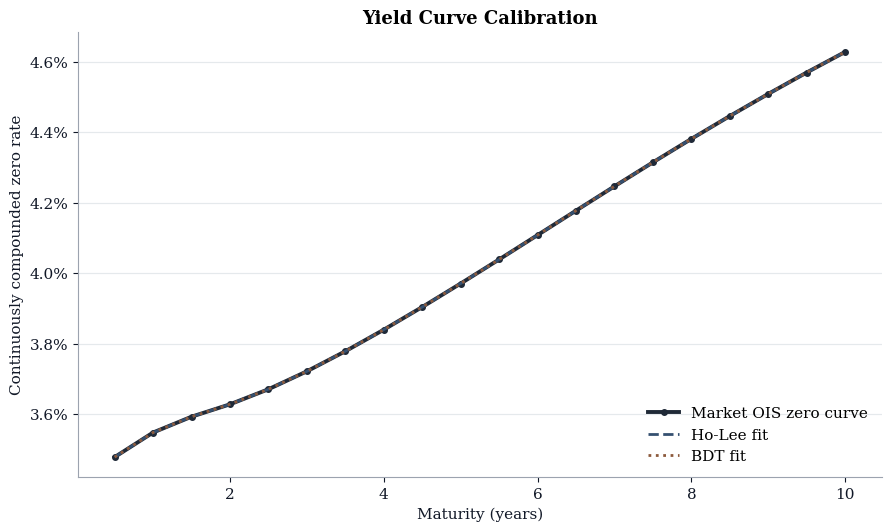

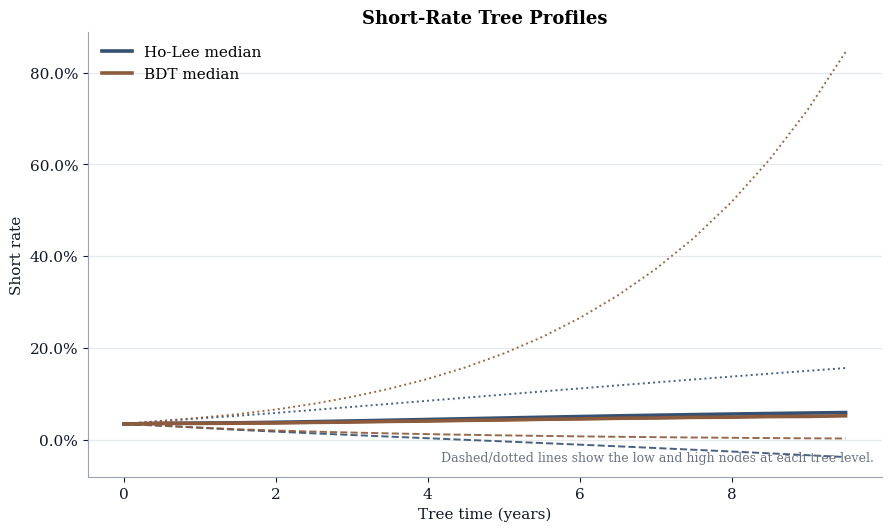

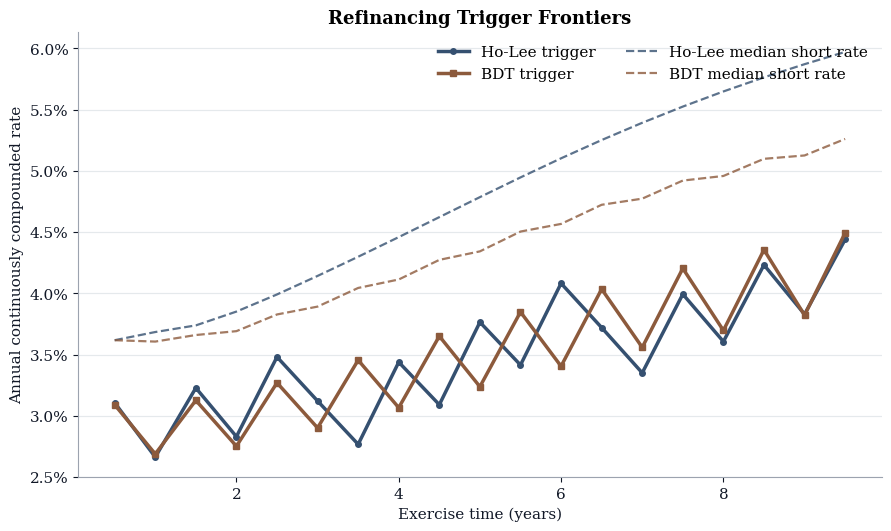

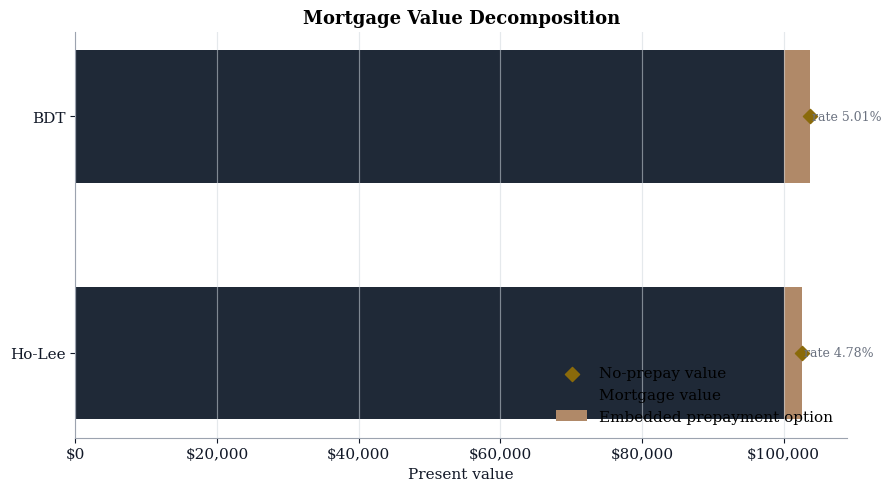

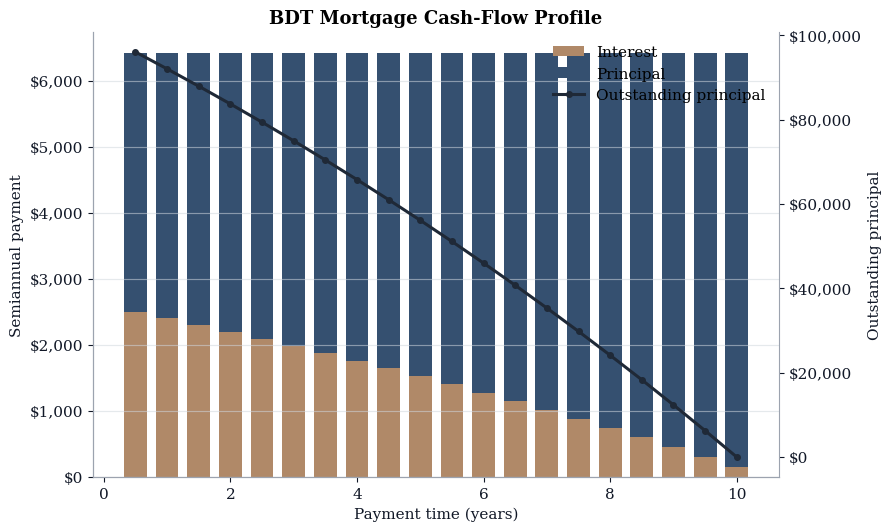

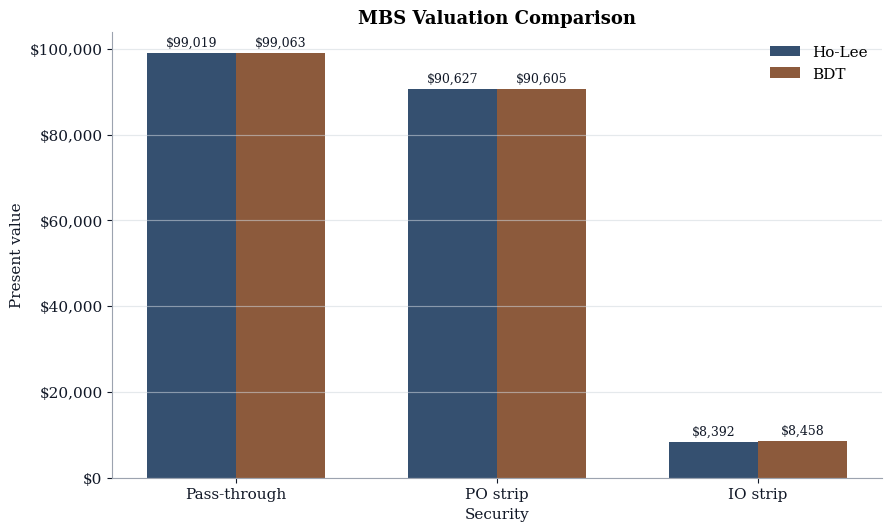

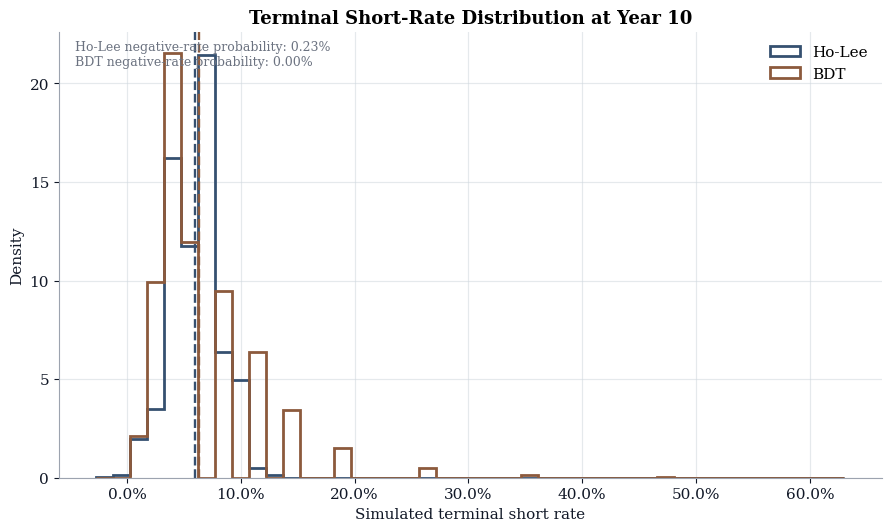

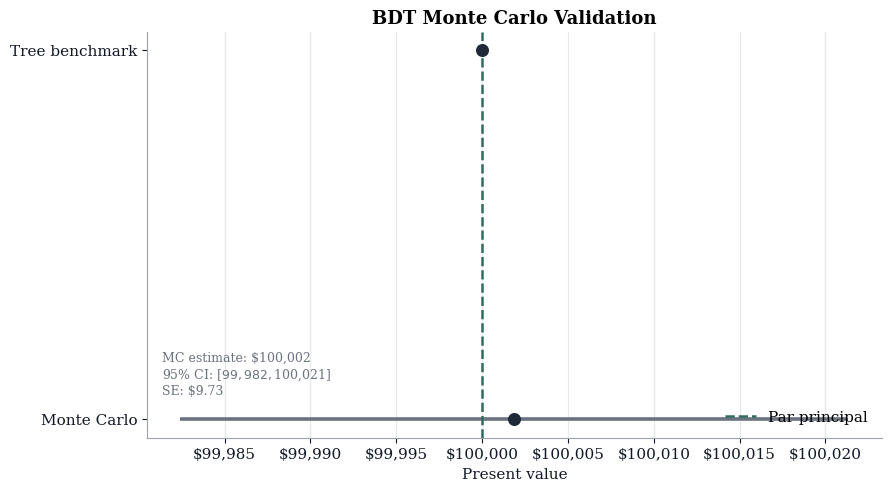

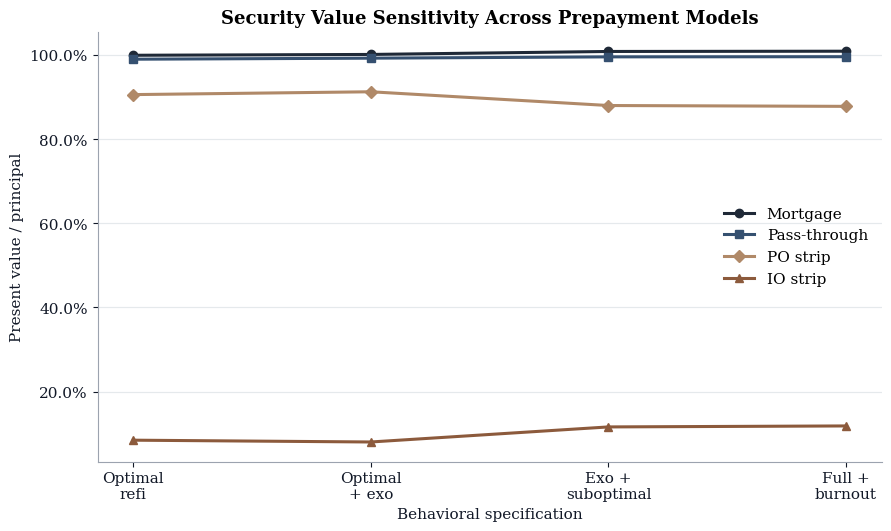

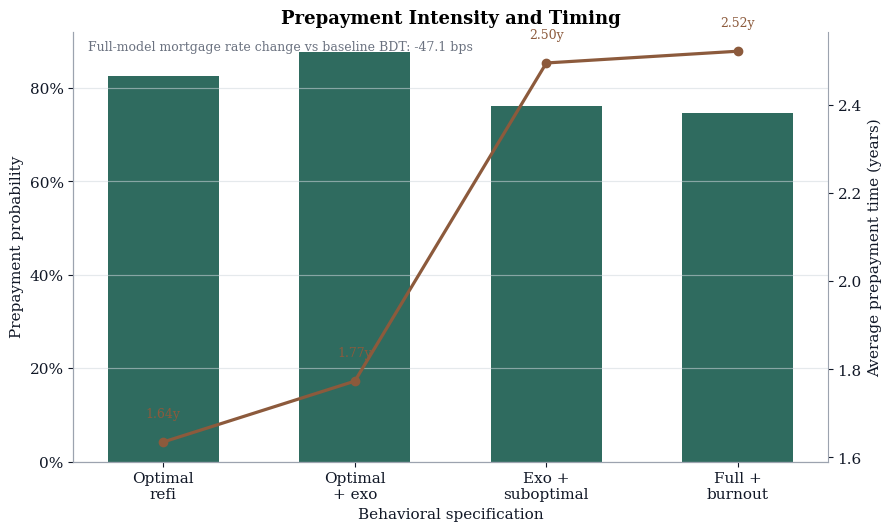

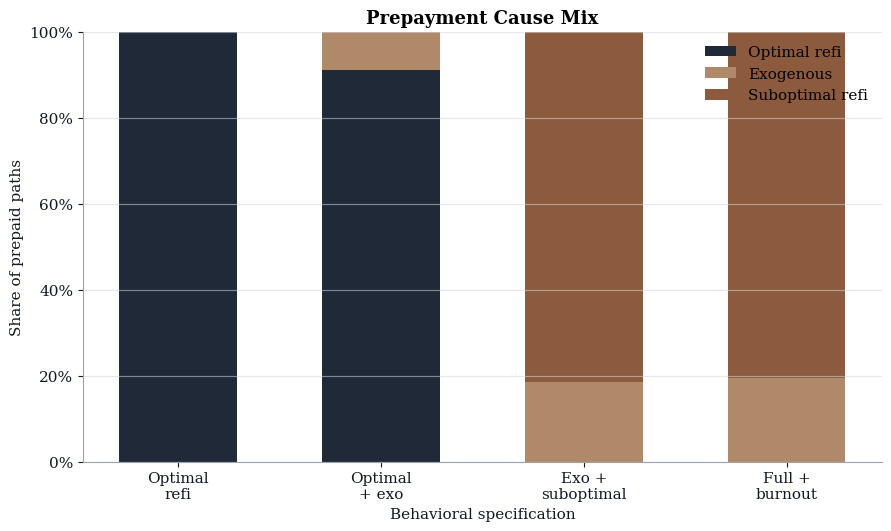

,figure,png
0,01_zero_curve_fit,figures/01_zero_curve_fit.png
1,02_short_rate_tree_profiles,figures/02_short_rate_tree_profiles.png
2,03_refinancing_trigger_frontiers,figures/03_refinancing_trigger_frontiers.png
3,04_mortgage_value_decomposition,figures/04_mortgage_value_decomposition.png
4,05_bdt_amortization_profile,figures/05_bdt_amortization_profile.png
5,06_mbs_valuation_comparison,figures/06_mbs_valuation_comparison.png
6,07_terminal_rate_distribution,figures/07_terminal_rate_distribution.png
7,08_bdt_mc_validation,figures/08_bdt_mc_validation.png
8,09_part_f_security_value_sensitivity,figures/09_part_f_security_value_sensitivity.png
9,10_part_f_prepayment_behavior,figures/10_part_f_prepayment_behavior.png


In [14]:
from paper_figures import build_paper_ready_figures

paper_figure_exports = build_paper_ready_figures(globals())
paper_figure_exports